# Bayes Ingenuo (Gaussiano) : (Gaussian) Naive Bayes
Ismael Quesada Salas

El método de Bayes Ingenuo es válido para problemas de clasificación y hace diferencia sobre si los datos de entrada son categóricos o numéricos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from collections import Counter 

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import GaussianNB

In [18]:
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

mypath = "pima-indians-diabetes.csv"

data = pd.read_csv(mypath, sep=",", header=None, names=columns)
data.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [19]:
X = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
Y = data[['Outcome']]

In [20]:
Counter(Y['Outcome'])

Counter({0: 500, 1: 268})

In [21]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size=0.7, random_state=7)

print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


In [22]:
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
modeloGNB = GaussianNB()
sol = cross_val_score(modeloGNB, Xtrain, np.ravel(ytrain), cv=kfold)
print(sol.mean())

0.7614954577218728


In [23]:
modeloGNB.fit(Xtrain, np.ravel(ytrain))
yhat = modeloGNB.predict(Xtest)

cm = confusion_matrix(ytest, np.ravel(yhat))    # los renglones son los reales y las columnas las predicciones.
print(cm)

[[116  31]
 [ 29  55]]


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay 

In [25]:
modelokNN = KNeighborsClassifier().fit(Xtrain, np.ravel(ytrain))
modelokNN.score(Xtest,ytest)

0.6883116883116883

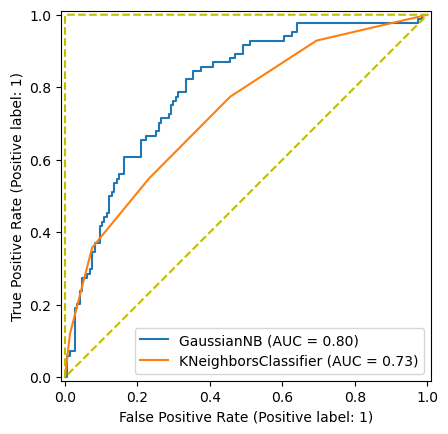

In [26]:
gnb_curve = RocCurveDisplay.from_estimator(modeloGNB, Xtest, ytest)
knn_curve = RocCurveDisplay.from_estimator(modelokNN, Xtest, ytest, ax=gnb_curve.ax_)

plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.show() 